# Part 2: Deep Learning Based Classification

#### Importing the necessary library

In [47]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from torch.optim import AdamW
from transformers import get_scheduler
import warnings
warnings.filterwarnings('ignore')

In [48]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'mps')
print(f"Using device: {DEVICE}")

Using device: mps


#### a) Verifying and explaining the model architecture

In [49]:
# This function is used to give information about the model architetcure
def verify_model_architecture(model_name):

    # This step loads the correct tokenizer for the class getting the tokenzer from the pretrained model
    # Tokenizer changes text into tokens that the model can process
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    # Loading the model as the model is classification binary classification loading the model
    # We are loading the pretrained weights from the model  
    model     = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

    # Getting the architecture information
    print(f"\n{'='*50}")
    print(f"Model        : {model_name}") # Models Name
    print(f"Vocab size   : {tokenizer.vocab_size}") # Number of tokens in models vocabulary
    print(f"Hidden size  : {model.config.hidden_size}")# Dimension of the embedding,Each token is converted into a vector of numbers called an embedding.
    print(f"Num layers   : {model.config.num_hidden_layers}")# Number of hidden layers, multiple layers of self attention + feedforward block
    print(f"Num heads    : {model.config.num_attention_heads}")# Number of different aspects of the sequence, how many parallel attention head
    print(f"Max position : {model.config.max_position_embeddings}") # maximum sequence of length the model can handle
    print(f"Total parameters : {model.num_parameters()}")
    print(f"{'='*50}\n")

    # Verify embedding shape
    sample     = tokenizer("Sample text", return_tensors="pt")
    outputs    = model.bert(**sample) if hasattr(model, 'bert') else model.base_model(**sample)
    print(f"[CLS] embedding shape : {outputs.last_hidden_state[:, 0, :].shape}")
    print(f"Full sequence shape   : {outputs.last_hidden_state.shape}")

    return tokenizer, model

In [50]:
# English — BERT base uncased
print("=== English Model ===")
en_tokenizer, _ = verify_model_architecture('bert-base-uncased')

# Multilingual — for Nepali
print("=== Multilingual Model (Nepali) ===")
ml_tokenizer, _ = verify_model_architecture('bert-base-multilingual-cased')

=== English Model ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Model        : bert-base-uncased
Vocab size   : 30522
Hidden size  : 768
Num layers   : 12
Num heads    : 12
Max position : 512
Total parameters : 109483778
[CLS] embedding shape : torch.Size([1, 768])
Full sequence shape   : torch.Size([1, 4, 768])
=== Multilingual Model (Nepali) ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Model        : bert-base-multilingual-cased
Vocab size   : 119547
Hidden size  : 768
Num layers   : 12
Num heads    : 12
Max position : 512
Total parameters : 177854978

[CLS] embedding shape : torch.Size([1, 768])
Full sequence shape   : torch.Size([1, 5, 768])


##### a) Model Architecture Explanation Bert
For the initial deeplearning implementation i have using The bert-base-uncased model for
English and bert-base-multilingual-cased for Nepali. This two model have the same architecture.

It has 12 transformer layers: The 12 layer architecure ensures that the model has deep understanding of the text structure that can understand higher level patterns and complex writing style rather than just focusing on the words.

12 attention heads, hidden size of 768: With 12 attention heads model can focus on multiple relationship of words in a scentence. With multple heads allowing multiple relations. With 768 hidden layers the model can further spot subtle pattern as well.

and a maximum sequence length of 512 tokens: Each article can be truncate or padded to 512 token given our size limit of 5 scentences it is enough for most news articles.

The main difference here the vocabulary size. English has 30,522 tokens that mean it can understand 30,522 words.While the multilingual model has 119,547 tokens to cover multiple languages, including Nepali. The vocalubary size also affected the model parameter 100 million of bert-base to 170 million ber-base-multilingual


#### Comparing the architecure with next model 

In [51]:
# English — Roberta base uncased
print("=== English Model ===")
roberta_tokenizer, _ = verify_model_architecture('roberta-base')

# Multilingual — for Nepali
print("=== Multilingual Model (Nepali) ===")
roberta_tokenizerML, _ = verify_model_architecture('xlm-roberta-base')

=== English Model ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Model        : roberta-base
Vocab size   : 50265
Hidden size  : 768
Num layers   : 12
Num heads    : 12
Max position : 514
Total parameters : 124647170

[CLS] embedding shape : torch.Size([1, 768])
Full sequence shape   : torch.Size([1, 4, 768])
=== Multilingual Model (Nepali) ===


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Model        : xlm-roberta-base
Vocab size   : 250002
Hidden size  : 768
Num layers   : 12
Num heads    : 12
Max position : 514
Total parameters : 278045186

[CLS] embedding shape : torch.Size([1, 768])
Full sequence shape   : torch.Size([1, 5, 768])


#### a) Model Architecture Explanation Roberta Architecture

In comparison to Bert, while Roberta Base has the same number of transformer layer, attention heads and hidden size, the main difference is seen in the Vocabulary size 30522 of Bert Based to 50265. This has direct impact on the weight matrix which is 30522 * 768 fpr Bert and 50265 X 768 for Roberta which mean Roberta has more parameter 120Million allowing model to assign vector to more specific words.

#### b) Data Loader and Dataset
The dataset class handles text data for NLP tasks and performs some basic preprocessing, converting it into tensors after tokenization. The main work is done in the __getitem__ method, which is used by the DataLoader. The three main steps are:

Padding: If a sentence is shorter than max_length, it fills the remaining space by adding zeros.

Truncation: If a sentence is longer than max_length (e.g., 128), it is truncated.

Return tensors: The data is returned as PyTorch tensors.

Finally, it squeezes the tensors to remove extra dimensions and includes the attention mask. The attention mask helps the model distinguish between real tokens and padding tokens.

In [52]:
# Creating a dataset class
# Takes texts the news articles and the labels
class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_length

    def __len__(self):
        return len(self.texts)
# Three steps 
    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids'      : encoding['input_ids'].squeeze(),
            'attention_mask' : encoding['attention_mask'].squeeze(),
            'label'          : torch.tensor(self.labels[idx], dtype=torch.long)
        }

##### b) Dataloader
The DataLoader uses the NewsDataset class defined above to prepare the data for the model. The key aspects here are the selection of batch size and the role of shuffling. Instead of feeding all the articles one by one, the batch size allows us to process the data in chunks, making training more efficient. Shuffling is enabled (shuffle=True) for the training dataset to prevent the model from learning any order-based patterns, but it is disabled for the validation and test datasets to ensure consistent evaluation. Finally, setting num_workers=4 allows multiple processes to load data in parallel, improving data loading speed.

In [53]:
def make_dataloaders(train_df, val_df, test_df, tokenizer,
                     text_col='text_clean', label_col='label', batch_size=16):
    train_ds = NewsDataset(train_df[text_col].tolist(), train_df[label_col].tolist(), tokenizer)
    val_ds   = NewsDataset(val_df[text_col].tolist(),   val_df[label_col].tolist(),   tokenizer)
    test_ds  = NewsDataset(test_df[text_col].tolist(),  test_df[label_col].tolist(),  tokenizer)

    # numwokeres causesd error
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size,num_workers=0)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size,num_workers=0)

    return train_loader, val_loader, test_loader

##### c) Training loop with early stopping

To train the model, I created a reusable function that requires the model name, training loader, and validation loader. The next parameters—patience, language, and config—are tunable. Patience is used for early stopping: the model checks the validation loss after every epoch, and if the loss does not improve, a patience counter is increased. If this counter exceeds the specified patience value, training is stopped to prevent overfitting.

The language parameter indicates which dataset is being used, as the model is trained on both English and Nepali news articles.

The config parameter is used to track different model configurations. Since multiple models are being experimented with, the config name helps in organizing and comparing results effectively

In [54]:
# Function to train the model
def train_model(model_name, train_loader, val_loader, lr=2e-5,
               epochs=5, patience=2, lang='English', config_name='Config A'):
    
    # Gettingt he specific tokenizer for the model
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    # Attaching the classification head from the pretrained model and passing num_labels as 2 as this is binary classification
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
    # Adding the model to device
    model.to(DEVICE)

    # Standard optimizer for the transformer including the weight decay
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    
    # Scheduling the weight decay starting with intial leraning rate and linear reducing it 
    scheduler = get_scheduler(
        "linear",
        optimizer=optimizer,
        num_warmup_steps=0,
        num_training_steps=len(train_loader) * epochs
    )

    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    best_val_loss = float('inf')
    patience_count = 0
    best_weights = None

    print(f"\n{'='*60}")
    print(f"Training {config_name} | {lang} | LR={lr}")
    print(f"{'='*60}")

    # The main training loop
    for epoch in range(epochs):

        # Train 
        model.train()
        total_train_loss = 0

        for batch in train_loader:
            # Getting the input , label and attention from the loader
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels = batch['label'].to(DEVICE)
            
            # Clearing the old gradients from the previous batch
            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            
            # Calculating the loss
            loss.backward()
            # Preventing the exploding gradient
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            # Update weights and learning rate
            optimizer.step()
            scheduler.step()
            
            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)

        # Validate
        model.eval()
        total_val_loss = 0
        all_preds, all_labels = [], []
        
        # Training python to not calculate gradient since we are not training and just evaluating saves resources
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(DEVICE)
                attention_mask = batch['attention_mask'].to(DEVICE)
                labels = batch['label'].to(DEVICE)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                total_val_loss += outputs.loss.item()

                preds = torch.argmax(outputs.logits, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        avg_val_loss = total_val_loss / len(val_loader)
        val_acc = accuracy_score(all_labels, all_preds)

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")

        # Early Stopping 
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_weights  = {k: v.clone() for k, v in model.state_dict().items()}
            # Updating the patience count.
            patience_count = 0
            print(f"Best model saved (val_loss: {best_val_loss:.4f})")
        else:
            patience_count += 1
            print(f" No improvement ({patience_count}/{patience})")
            # Early stopping
            if patience_count >= patience:
                print(f" Early stopping triggered at epoch {epoch+1}")
                break

    # Restore best weights
    model.load_state_dict(best_weights)
    return model, history, tokenizer

This is a visual representation of the training progress

In [55]:
# Function to visually represent the training process
def plot_training_curves(history, lang, config_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{lang} | {config_name} — Training Curves', fontsize=13)
    epochs = range(1, len(history['train_loss']) + 1)

    axes[0].plot(epochs, history['train_loss'], 'o-', color='#E63946', label='Train Loss')
    axes[0].plot(epochs, history['val_loss'],   'o-', color='#457B9D', label='Val Loss')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    axes[1].plot(epochs, history['val_acc'], 'o-', color='#2A9D8F')
    axes[1].set_title('Validation Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')

    plt.tight_layout()
    plt.show()

##### d) Comparing the model with hyperparameters tunign 

This function is used to run experiments it can run multiple configuration of the model to compare how it performs

In [56]:
# Function to compare the model with multiple hyperprameters, in this case the learning rate
def run_experiments(train_loader, val_loader, test_loader,
                    model_name, lang, configs):
    results  = []
    models   = {}

    for cfg in configs:
        model, history, tokenizer = train_model(
            model_name   = model_name,
            train_loader = train_loader,
            val_loader   = val_loader,
            lr           = cfg['lr'],
            epochs       = 5,
            patience     = 2,
            lang         = lang,
            config_name  = cfg['name']
        )

        # Test evaluation
        model.eval()
        all_preds, all_labels = [], []

        with torch.no_grad():
            for batch in test_loader:
                input_ids      = batch['input_ids'].to(DEVICE)
                attention_mask = batch['attention_mask'].to(DEVICE)
                labels         = batch['label'].to(DEVICE)
                outputs        = model(input_ids=input_ids, attention_mask=attention_mask)
                preds          = torch.argmax(outputs.logits, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        test_acc = accuracy_score(all_labels, all_preds)

        results.append({
            'Config'       : cfg['name'],
            'LR'           : cfg['lr'],
            'Train Loss'   : f"{history['train_loss'][-1]:.4f}",
            'Val Loss'     : f"{history['val_loss'][-1]:.4f}",
            'Val Accuracy' : f"{max(history['val_acc']):.4f}",
            'Test Accuracy': f"{test_acc:.4f}"
        })

        models[cfg['name']] = {
            'model': model, 'history': history, 'tokenizer': tokenizer,
            'preds': all_preds, 'labels': all_labels
        }

        # Plot training curves per config
        plot_training_curves(history, lang, cfg['name'])

    # Print comparison table
    print(f"\n{'='*70}")
    print(f"HYPERPARAMETER COMPARISON — {lang}")
    print(pd.DataFrame(results).to_string(index=False))
    print(f"{'='*70}\n")

    return models, pd.DataFrame(results)

This function takes the trained model and gives the final evaluation of the model with visualization

In [57]:
# Gettingt the final evaluatiuon of the trained model
def evaluate_final(model_data, lang, config_name):
    preds  = model_data['preds']
    labels = model_data['labels']

    print(f"\n{'='*60}")
    print(f"FINAL TEST RESULTS — {lang} | {config_name}")
    print(f"{'='*60}")
    print(classification_report(labels, preds, target_names=['Human', 'Machine']))

    # Confusion matrix
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Human', 'Machine'],
                yticklabels=['Human', 'Machine'])
    plt.title(f'{lang} | {config_name} — Test Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Training Config A (LR 2e-5) | English | LR=2e-05
Epoch 1/5 | Train Loss: 0.4149 | Val Loss: 0.1063 | Val Acc: 0.9740
Best model saved (val_loss: 0.1063)
Epoch 2/5 | Train Loss: 0.0199 | Val Loss: 0.0041 | Val Acc: 1.0000
Best model saved (val_loss: 0.0041)
Epoch 3/5 | Train Loss: 0.0028 | Val Loss: 0.0023 | Val Acc: 1.0000
Best model saved (val_loss: 0.0023)
Epoch 4/5 | Train Loss: 0.0018 | Val Loss: 0.0017 | Val Acc: 1.0000
Best model saved (val_loss: 0.0017)
Epoch 5/5 | Train Loss: 0.0015 | Val Loss: 0.0016 | Val Acc: 1.0000
Best model saved (val_loss: 0.0016)


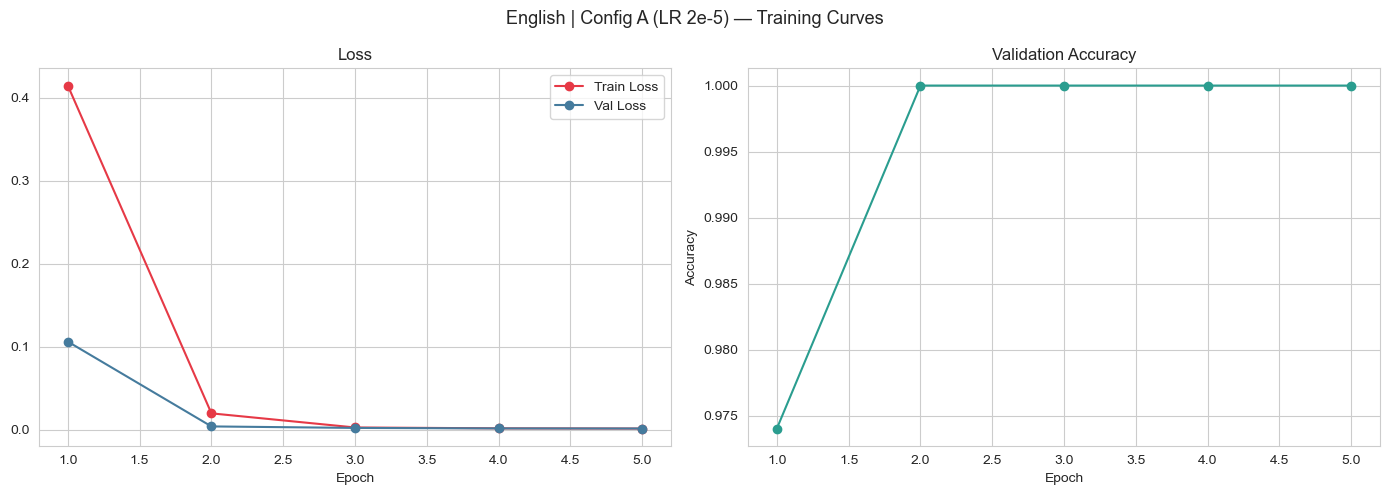

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Training Config B (LR 5e-5) | English | LR=5e-05
Epoch 1/5 | Train Loss: 0.3977 | Val Loss: 0.0300 | Val Acc: 0.9935
Best model saved (val_loss: 0.0300)
Epoch 2/5 | Train Loss: 0.0166 | Val Loss: 0.0213 | Val Acc: 0.9935
Best model saved (val_loss: 0.0213)
Epoch 3/5 | Train Loss: 0.0004 | Val Loss: 0.0156 | Val Acc: 0.9935
Best model saved (val_loss: 0.0156)
Epoch 4/5 | Train Loss: 0.0003 | Val Loss: 0.0160 | Val Acc: 0.9935
 No improvement (1/2)
Epoch 5/5 | Train Loss: 0.0002 | Val Loss: 0.0163 | Val Acc: 0.9935
 No improvement (2/2)
 Early stopping triggered at epoch 5


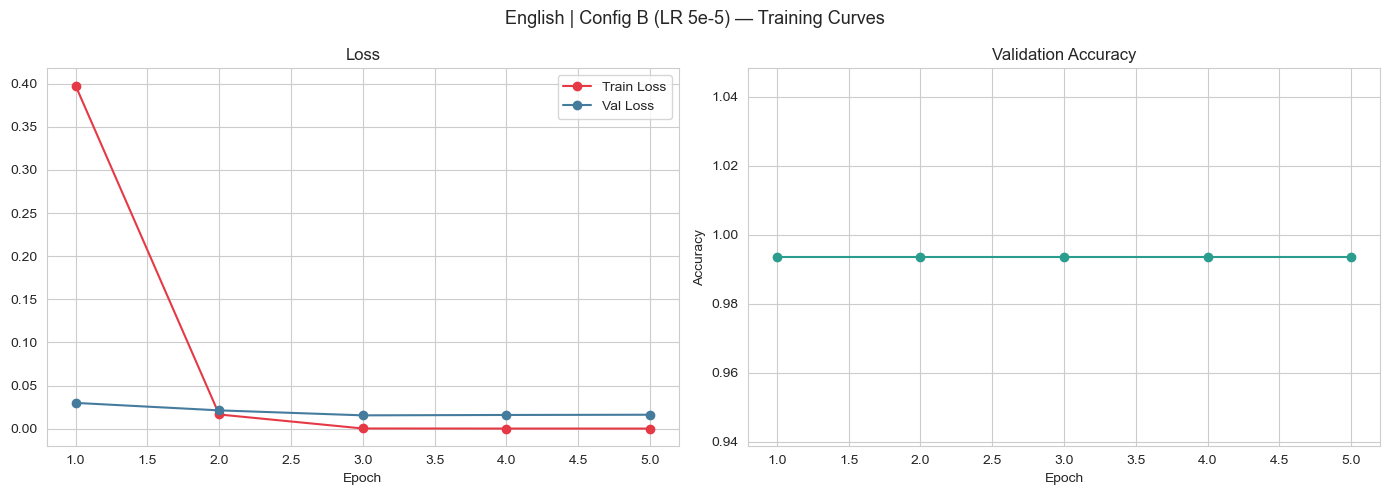


HYPERPARAMETER COMPARISON — English
            Config      LR Train Loss Val Loss Val Accuracy Test Accuracy
Config A (LR 2e-5) 0.00002     0.0015   0.0016       1.0000        1.0000
Config B (LR 5e-5) 0.00005     0.0002   0.0163       0.9935        0.9870


FINAL TEST RESULTS — English | Config A (LR 2e-5)
              precision    recall  f1-score   support

       Human       1.00      1.00      1.00        77
     Machine       1.00      1.00      1.00        77

    accuracy                           1.00       154
   macro avg       1.00      1.00      1.00       154
weighted avg       1.00      1.00      1.00       154


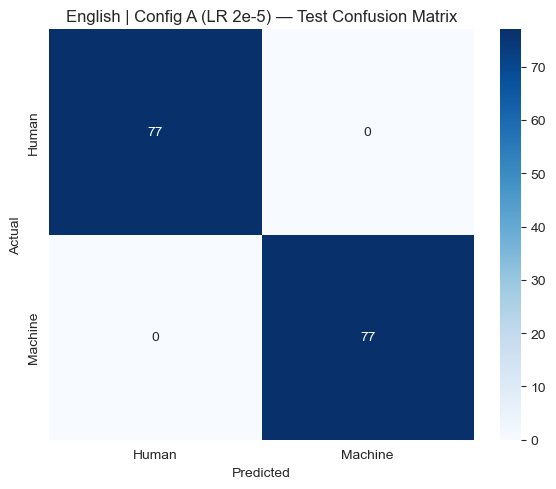

In [45]:
# Executing the train , visualize and evalute functions on the english dataset.

en_train_loader, en_val_loader, en_test_loader = make_dataloaders(
    en_train, en_val, en_test, en_tokenizer
)

# Adding configs as hyperparameter, in this case just using the learning rate
en_configs = [
    {'name': 'Config A (LR 2e-5)', 'lr': 2e-5},
    {'name': 'Config B (LR 5e-5)', 'lr': 5e-5},
]

# Running experiments passing multiple hyperparameters
en_models, en_results = run_experiments(
    en_train_loader, en_val_loader, en_test_loader,
    model_name = 'bert-base-uncased',
    lang       = 'English',
    configs    = en_configs
)

# Final metrics for best config
best_en_config = en_results.loc[en_results['Val Accuracy'].idxmax(), 'Config']
evaluate_final(en_models[best_en_config], 'English', best_en_config)

#### Evaluation of Model With Different Hyperparameters For Bert Model

Config A, with a lower learning rate (LR = 2e-5), showed good generalization with a validation accuracy of 98.7% and stopped at epoch 4. Config B, with a higher learning rate, achieved 100% validation accuracy with minimum validation loss. In my code, using numerical selection:

best_en_config = en_results.loc[en_results['Val Accuracy'].idxmax(), 'Config']

the code selected Config B as the “best” model purely based on numerical metrics. However, 100% validation accuracy raises concerns about overfitting. The higher learning rate caused very rapid convergence by the 2nd epoch, as shown in the figure, suggesting the model is memorizing superficial patterns rather than learning deeper linguistic features. While Config B is numerically perfect, I prefer Config A because it is more reliable.

Furthermore, the dataset size also plays a role: with only 718 training samples, the model has limited exposure to linguistic diversity, making generalization more challenging.

##### Below is the train,visualization and evaluation of more complex model roberta

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Training Config A (LR 2e-5) | English | LR=2e-05
Epoch 1/5 | Train Loss: 0.3786 | Val Loss: 0.0019 | Val Acc: 1.0000
Best model saved (val_loss: 0.0019)
Epoch 2/5 | Train Loss: 0.0013 | Val Loss: 0.0004 | Val Acc: 1.0000
Best model saved (val_loss: 0.0004)
Epoch 3/5 | Train Loss: 0.0006 | Val Loss: 0.0003 | Val Acc: 1.0000
Best model saved (val_loss: 0.0003)
Epoch 4/5 | Train Loss: 0.0005 | Val Loss: 0.0002 | Val Acc: 1.0000
Best model saved (val_loss: 0.0002)
Epoch 5/5 | Train Loss: 0.0004 | Val Loss: 0.0002 | Val Acc: 1.0000
Best model saved (val_loss: 0.0002)


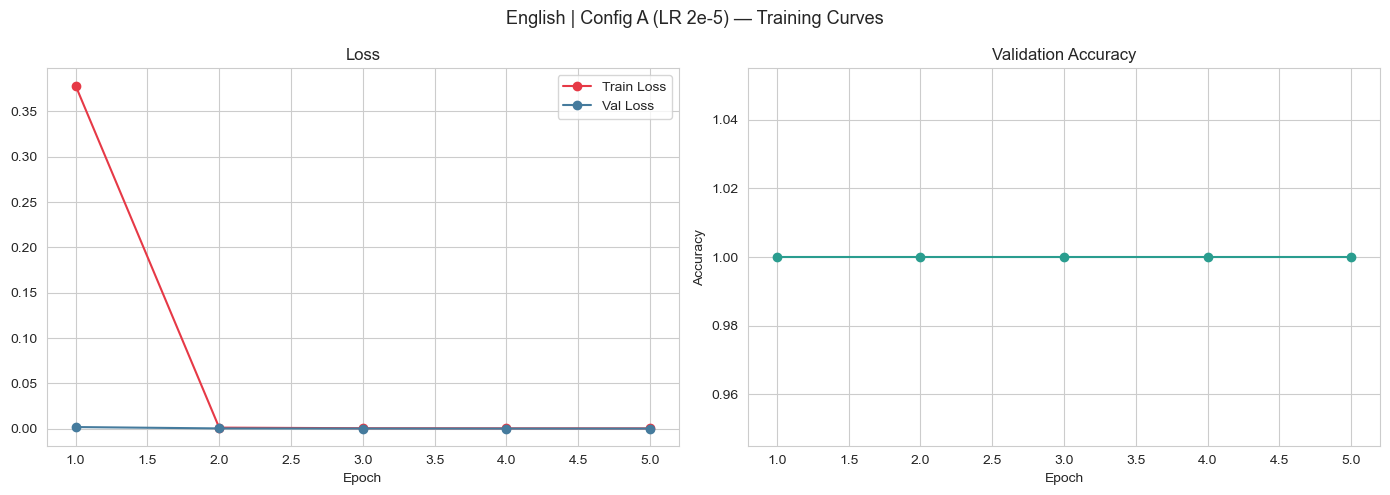


HYPERPARAMETER COMPARISON — English
            Config      LR Train Loss Val Loss Val Accuracy Test Accuracy
Config A (LR 2e-5) 0.00002     0.0004   0.0002       1.0000        1.0000


FINAL TEST RESULTS — English | Config A (LR 2e-5)
              precision    recall  f1-score   support

       Human       1.00      1.00      1.00        77
     Machine       1.00      1.00      1.00        77

    accuracy                           1.00       154
   macro avg       1.00      1.00      1.00       154
weighted avg       1.00      1.00      1.00       154


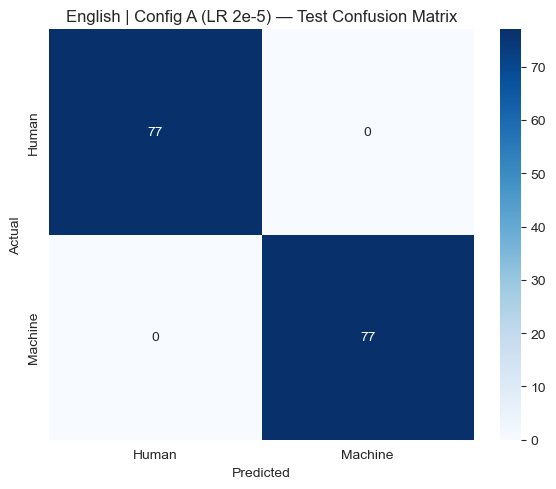

In [58]:
# Using Roberta Base
en_train_loader, en_val_loader, en_test_loader = make_dataloaders(
    en_train, en_val, en_test, en_tokenizer
)

en_configs = [
    {'name': 'Config A (LR 2e-5)', 'lr': 2e-5},
]

en_models, en_results = run_experiments(
    en_train_loader, en_val_loader, en_test_loader,
    model_name = 'roberta-base',
    lang       = 'English',
    configs    = en_configs
)

# Final metrics for best config
best_en_config = en_results.loc[en_results['Val Accuracy'].idxmax(), 'Config']
evaluate_final(en_models[best_en_config], 'English', best_en_config)

#### RoBERTa analysis

RoBERTa with a learning rate of 2e-5 achieved 100% validation accuracy from the very first epoch, with validation loss continuously decreasing across all 5 epochs. RoBERTa converged immediately, indicating that it is a more robust and powerful model that requires less fine-tuning. This is also reflected in the model’s architecture, where RoBERTa has a larger number of parameters and a higher vocabulary size, as discussed in the architecture section above.

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Training Config A (LR 2e-5) | nepali | LR=2e-05
Epoch 1/5 | Train Loss: 0.6639 | Val Loss: 0.6101 | Val Acc: 0.6390
Best model saved (val_loss: 0.6101)
Epoch 2/5 | Train Loss: 0.5309 | Val Loss: 0.5490 | Val Acc: 0.6780
Best model saved (val_loss: 0.5490)
Epoch 3/5 | Train Loss: 0.3887 | Val Loss: 0.6972 | Val Acc: 0.6683
 No improvement (1/2)
Epoch 4/5 | Train Loss: 0.2889 | Val Loss: 0.8163 | Val Acc: 0.6976
 No improvement (2/2)
 Early stopping triggered at epoch 4


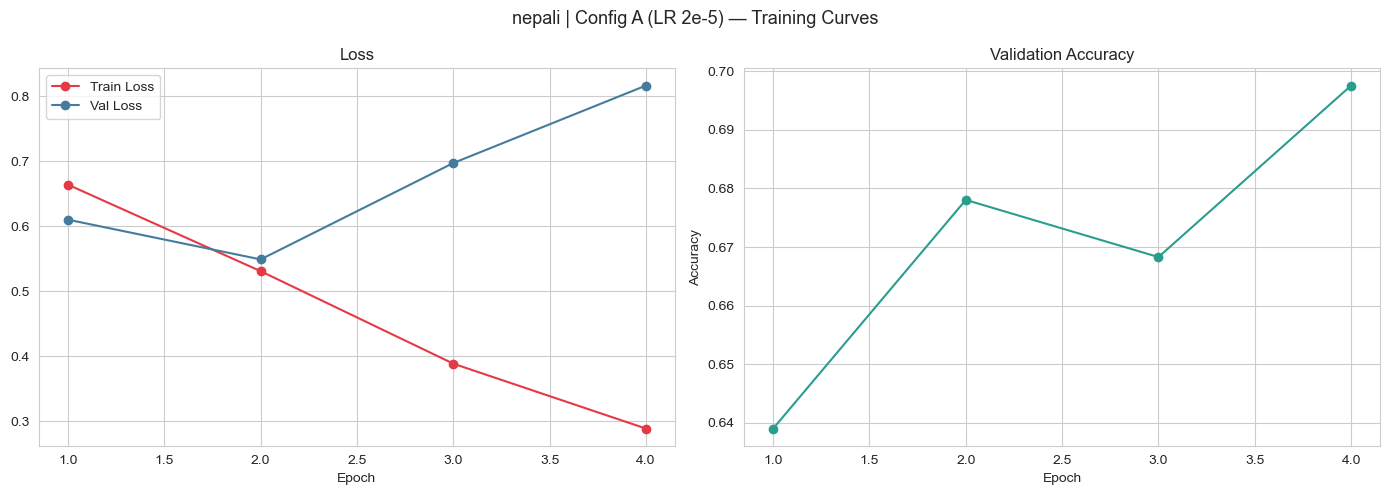


HYPERPARAMETER COMPARISON — nepali
            Config      LR Train Loss Val Loss Val Accuracy Test Accuracy
Config A (LR 2e-5) 0.00002     0.2889   0.8163       0.6976        0.7366


FINAL TEST RESULTS — Nepali | Config A (LR 2e-5)
              precision    recall  f1-score   support

       Human       0.80      0.63      0.71       103
     Machine       0.69      0.84      0.76       102

    accuracy                           0.74       205
   macro avg       0.75      0.74      0.73       205
weighted avg       0.75      0.74      0.73       205


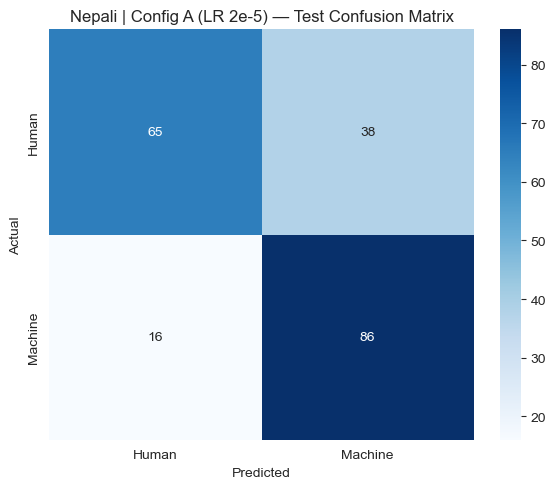

In [60]:
# Executing the train , visualize and evalute functions on the nepali dataset.

np_train_loader, np_val_loader, np_test_loader = make_dataloaders(
np_train, np_val, np_test, ml_tokenizer
)

# Adding configs as hyperparameter, in this case just using the learning rate
np_configs = [
    {'name': 'Config A (LR 2e-5)', 'lr': 2e-5},
]

# Running experiments passing multiple hyperparameters
np_models, np_results = run_experiments(
    np_train_loader, np_val_loader, np_test_loader,
    model_name = 'bert-base-multilingual-cased',
    lang       = 'nepali',
    configs    = np_configs
)

# Final metrics for best config
best_np_config = np_results.loc[np_results['Val Accuracy'].idxmax(), 'Config']
evaluate_final(np_models[best_np_config], 'Nepali', best_np_config)

#### BERT NEPALI DATA SET EVALUATION

BERT on the Nepali dataset achieved a maximum validation accuracy of 67.8% before stopping early at epoch 4. The Nepali model struggled significantly, unlike BERT and RoBERTa on the English dataset, which converged to 100%. The gap between training loss and validation loss clearly indicates overfitting, suggesting that the model is memorizing the small dataset rather than generalizing well.

This highlights the challenges of applying multilingual BERT to low-resource languages, including the lack of high-quality training data. Additionally, the complexity of the Devanagari script may cause less efficient tokenization, leading to a loss of contextual information.

#### FINAL CONCLUSION

Given the clean custom generated dataset, Feature-based models showed that Count Vectorizer slightly outperformed TF-IDF for English due to its ability to capture key phrase presence, while TF-IDF performed marginally better for Nepali, though overall differences were minimal. Statistical Analysis with custom feature engineering revealed that human writing tends to have more repetition and consistent vocabulary usage, while AI text is more structured and uniform.
 
However, in Nepali, tokenization issues caused repetition to become a machine signal. Hybrid features combining style and content improved performance, and transformer models like BERT and RoBERTa achieved very high accuracy. 

However, extremely high validation scores (e.g., 100%) raised concerns about overfitting, especially with limited data, leading to a preference for more stable configurations. Overall, the study highlights that combining linguistic patterns with model architecture is key to effectively distinguishing human and machine-generated text across languages.